<a href="https://colab.research.google.com/github/ravindu912/Deep-Learning/blob/main/IT23202986Q2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Task 2 - Implementing LSTM for Time-Series Forecasting**


***Read the following descriptions and instructions***

Time-series forecasting is a crucial task in various fields, including finance, economics, and weather prediction. In this question, you'll work with Long Short-Term Memory (LSTM) networks, a type of recurrent neural network (RNN) that is particularly effective at learning from sequences of data. LSTMs are designed to capture long-term dependencies in time-series data, making them well-suited for predicting future values based on historical patterns.

In this task, you will implement an LSTM model to forecast stock prices using historical data. Specifically, you'll use the closing prices of a stock to predict future prices, which is a common real-world application of time-series analysis in financial markets. This exercise will help you understand the principles of sequence modeling and how LSTMs can be applied to complex prediction tasks.

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

In [ ]:
# 1. Load and Preprocess the Data
def load_data(file_path):
    df = pd.read_csv(file_path)
    return df['Close'].values  # Use the 'Close' price for prediction

In [ ]:
# 2. Prepare the Dataset for LSTM
def create_dataset(data, time_step=60):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:(i + time_step)])
        y.append(data[i + time_step])
    return np.array(X), np.array(y)

In [ ]:
# Load Data
file_path = 'GOOG.csv'  # Path to the dataset in Colab or Jupyter home directory
data = load_data(file_path)

In [ ]:
# Normalize the Data
scaler = MinMaxScaler(feature_range=(0, 1))
data = scaler.fit_transform(data.reshape(-1, 1)).reshape(-1)

**time_step = 60:** This variable defines the length of the input sequence, meaning we will use the past 60 days of stock prices to predict the next day's closing price. This value is chosen to capture enough historical information to make an accurate prediction. You can change and try

In [ ]:

# Create the Dataset
time_step = 60  # Using 60 days of data to predict the next day's price
X, y = create_dataset(data, time_step)

In [ ]:
# Reshape for LSTM input [samples, time steps, features]
X = X.reshape(X.shape[0], X.shape[1], 1)

In [ ]:
# Split the Data into Training and Testing Sets (80% train, 20% test)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

***Modify the number of units in the LSTM layers and consider adding more layers or changing the dropout rate to see how these adjustments affect the model's performance***

Experiment with 'units'

Experiment with dropout for regularization

Add another LSTM layer



In [ ]:
from tensorflow.keras.layers import Input

# 3. Define the LSTM Model
model = Sequential([
    # 1. Clean Input Layer (eliminates the Keras warning)
    Input(shape=(time_step, 1)),

    # 2. Layer 1 with adjusted units
    LSTM(units=64, return_sequences=True),
    Dropout(0.2),

    # 3. Layer 2 (NEW intermediate stacked layer)
    LSTM(units=64, return_sequences=True),
    Dropout(0.2),

    # 4. Layer 3 (Adjusted units)
    LSTM(units=32, return_sequences=False),
    Dropout(0.2),

    # 5. Added intermediate Dense layer
    Dense(units=25, activation='relu'),
    Dense(units=1)
])

# 6. Changed loss function to MSE
model.compile(optimizer='adam', loss='mean_squared_error')

***Adjust the epochs and batch_size during the training phase to optimize the model’s learning process and its ability to generalize.***

In [ ]:
# 4. Train the Model with validation tracking
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 130ms/step - loss: 0.2931 - val_loss: 0.0215
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - loss: 0.0654 - val_loss: 0.0401
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 0.0399 - val_loss: 0.0320
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - loss: 0.0285 - val_loss: 0.0244
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - loss: 0.0227 - val_loss: 0.0187
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 0.0222 - val_loss: 0.0147
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - loss: 0.0197 - val_loss: 0.0144
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 0.0215 - val_loss: 0.0145
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - loss: 0.0172 - val_loss: 0.0144
Epoch 10/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - loss: 0.0210 - val_loss: 0.0149
Epoch 11/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - loss: 0.0176 - val_loss: 0.0183
Epoch 12/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - loss:

In [ ]:
# 5. Predict on the Test Data
y_pred = model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 642ms/step


In [ ]:
# Inverse transform to get the original scale
y_pred = scaler.inverse_transform(y_pred.reshape(-1, 1)).reshape(-1)
y_test = scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(-1)

***Analyze the plot to evaluate the model performance. Consider modifying the model architecture or training parameters to improve accuracy***

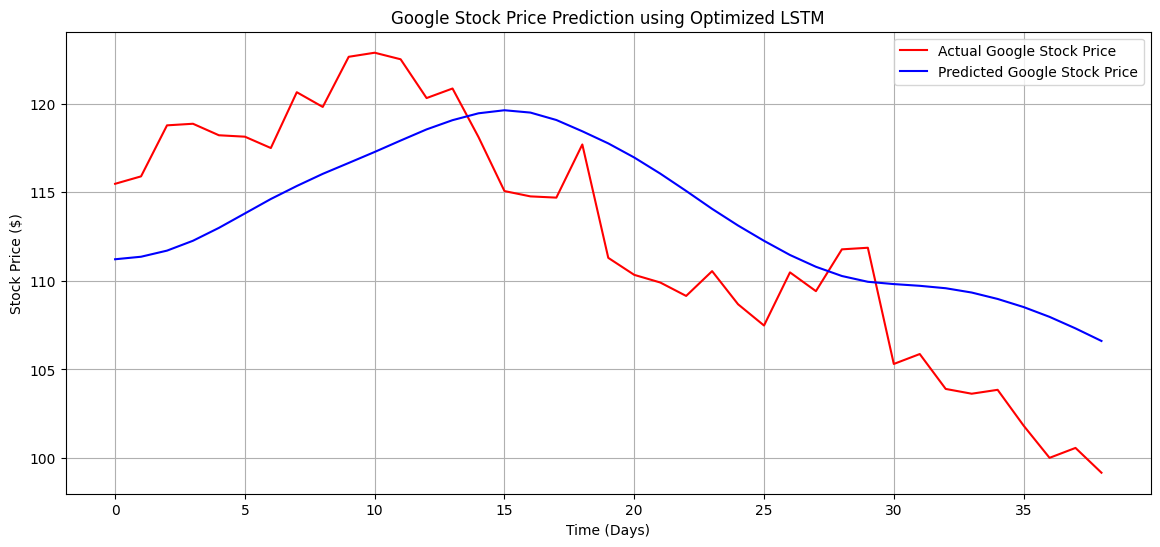

In [ ]:
# 6. Plot the Results
plt.figure(figsize=(14, 6))
plt.plot(y_test, color='red', label='Actual Google Stock Price')
plt.plot(y_pred, color='blue', label='Predicted Google Stock Price')
plt.xlabel('Time (Days)')
plt.ylabel('Stock Price ($)')
plt.title('Google Stock Price Prediction using Optimized LSTM')
plt.legend()
plt.grid(True)
plt.show()

***Answer the following questions. (You can type answers in a text cell)***
1.	What is the purpose of normalizing the 'Close' prices before feeding them into the LSTM model?
2.	What is the purpose of the Dropout layer in the LSTM model?
3.	In the plot showing actual vs predicted stock prices, what does it indicate if the predicted line closely follows the actual line?


1. What is the purpose of normalizing the 'Close' prices before feeding them into the LSTM model?Prevents Vanishing/Exploding Gradients: LSTMs rely on internal activation functions ($\tanh$ and $\text{sigmoid}$) which saturate at very large or small inputs. Scaling data between $0$ and $1$ keeps gradient computations stable during backpropagation.Faster Optimizer Convergence: Normalization ensures all feature values have uniform variance, allowing gradient descent optimizers (like Adam) to converge smoothly and much faster.Eliminates Scale Bias: It prevents historical periods with large absolute price numbers from dominating the weight updates over periods with smaller values.

2. What is the purpose of the Dropout layer in the LSTM model?
Prevents Overfitting: Dropout randomly ignores a chosen percentage of neurons (e.g., 20%) during each training iteration.

Encourages Generalized Learning: By breaking co-dependencies among neighboring units, it forces the network to learn robust feature representations instead of memorizing specific training sequences and noise.

3. In the plot showing actual vs predicted stock prices, what does it indicate if the predicted line closely follows the actual line?Sequential Trend Capture: It indicates that the LSTM model has successfully learned temporal dependencies and short-term price momentum from the 60-day historical window.Lag/Persistence Effect: In autoregressive stock price forecasting, a prediction curve closely tracking the actual curve typically reflects the network learning that $y_t \approx y_{t-1}$. While this shows strong directional tracking, it indicates the model is primarily predicting one-step persistence rather than long-term market volatility.

